<a href="https://colab.research.google.com/github/margaretabiodun-oyewuwo/Telecom-Customer-Churn-Analysis/blob/main/Forecasting_Tomato_Price_in_Nigeria_Using_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Tomato Price in Nigeria Using Time-Series Analysis

## Project Overview

This project analyses historical tomato retail prices and develops a time-series forecasting model to predict future monthly tomato prices.

The analysis uses historical tomato price records, which were cleaned, filtered, and aggregated into monthly average prices. Three forecasting approaches were evaluated: Naive Forecast, Exponential Smoothing, and ARIMA.

The models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The best-performing model was then used to forecast tomato prices for the following 12 months.


## 1. Introduction

Tomato prices can change over time due to changes in supply, demand, production conditions, transportation costs, and other market factors. Forecasting future prices can provide useful information for producers, traders, consumers, and other stakeholders.

This project uses time-series forecasting techniques to analyse historical monthly tomato retail prices and estimate future tomato prices.

## 2. Project Objective

The main objective of this project is to develop a time-series forecasting model for monthly tomato retail prices.

### Specific Objectives

1. Clean and prepare the historical tomato price data.
2. Aggregate tomato prices into monthly average prices.
3. Examine the historical trend in tomato prices.
4. Develop and compare different forecasting models.
5. Evaluate the models using MAE and RMSE.
6. Select the best-performing model.
7. Forecast tomato prices for the following 12 months.


## 3. Data Preparation

The original dataset contained 60,565 records and 16 columns, including information such as date, commodity, price, price type, and unit.

The dataset was cleaned by converting the date field to datetime format and ensuring that prices were represented numerically.

The analysis was then restricted to tomato retail prices measured at 0.5 KG. The resulting tomato records were aggregated by month using the mean price.

This produced 93 monthly observations covering December 2016 to May 2025.


In [1]:
import pandas as pd
import os

# Find the CSV file automatically
csv_files = [f for f in os.listdir('/content') if f.endswith('.csv')]

# Load the first CSV file found
file_path = os.path.join('/content', csv_files[0])
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

/tmp/ipykernel_1784/441099863.py:9: DtypeWarning: Columns (4,5,6,9,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,#date,#adm1+name,#adm2+name,#loc+market+name,#loc+market+code,#geo+lat,#geo+lon,#item+type,#item+name,#item+code,#item+unit,#item+price+flag,#item+price+type,#currency+code,#value,#value+usd
1,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
2,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
3,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,358.7,3.14
4,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,155.61,1.36


In [2]:
# Remove the metadata/description row
df = df[df['date'] != '#date'].copy()

# Display the first 5 actual records
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
1,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
2,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
3,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,358.7,3.14
4,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,155.61,1.36
5,2002-01-15,Sokoto,Gada,Illela (CBM),1037,13.64,5.28,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,153.35,1.34


In [3]:
df.shape


(60565, 16)

In [4]:
df['commodity'].unique()

array(['Maize', 'Millet', 'Rice (imported)', 'Sorghum', 'Beans (niebe)',
       'Wheat', 'Maize (white)', 'Sorghum (white)',
       'Rice (milled, local)', 'Bread', 'Cassava meal (gari, yellow)',
       'Gari (white)', 'Maize (yellow)', 'Rice (local)',
       'Sorghum (brown)', 'Yam (Abuja)', 'Fuel (diesel)',
       'Fuel (petrol-gasoline)', 'Cowpeas (brown)', 'Yam', 'Oil (palm)',
       'Cowpeas (white)', 'Groundnuts (shelled)', 'Maize flour',
       'Meat (goat)', 'Milk (powder)', 'Oil (vegetable)', 'Beans (red)',
       'Onions', 'Fish', 'Meat (beef)', 'Beans (white)', 'Groundnuts',
       'Eggs', 'Oranges', 'Spinach', 'Watermelons', 'Bananas', 'Tomatoes',
       'Cowpeas', 'Salt', 'Sugar'], dtype=object)

In [5]:
# Check how many tomato observations we have
tomato_df = df[df['commodity'] == 'Tomatoes'].copy()

print("Number of tomato records:", len(tomato_df))
print("\nPrice types:")
print(tomato_df['pricetype'].value_counts())

print("\nUnits:")
print(tomato_df['unit'].value_counts())

print("\nDate range:")
print(tomato_df['date'].min(), "to", tomato_df['date'].max())

Number of tomato records: 1178

Price types:
pricetype
Retail    1178
Name: count, dtype: int64

Units:
unit
0.5 KG    1178
Name: count, dtype: int64

Date range:
2016-12-15 to 2025-05-15


In [6]:
# Make a copy of the tomato dataset
tomato_df = df[df['commodity'] == 'Tomatoes'].copy()

# Convert date to datetime
tomato_df['date'] = pd.to_datetime(tomato_df['date'], errors='coerce')

# Convert price to numeric
tomato_df['price'] = pd.to_numeric(tomato_df['price'], errors='coerce')

# Check the data types
print(tomato_df[['date', 'price']].dtypes)

# Check for missing values
print("\nMissing values:")
print(tomato_df[['date', 'price']].isnull().sum())

date     datetime64[ns]
price           float64
dtype: object

Missing values:
date     0
price    0
dtype: int64


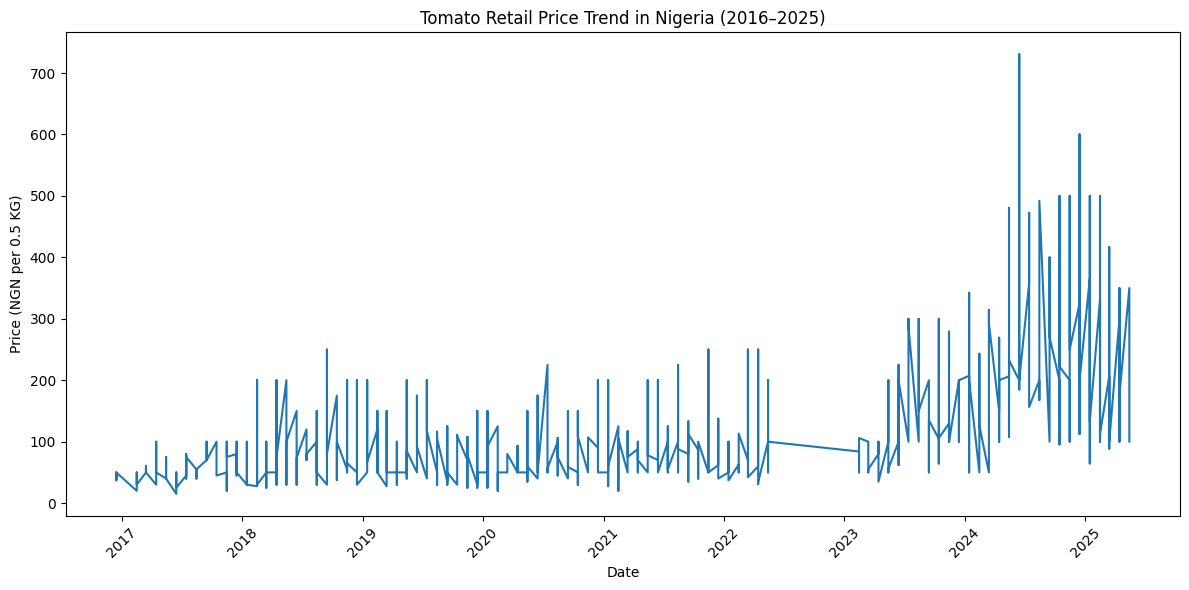

In [7]:
import matplotlib.pyplot as plt

# Sort the data by date
tomato_df = tomato_df.sort_values('date')

# Plot tomato price over time
plt.figure(figsize=(12, 6))

plt.plot(tomato_df['date'], tomato_df['price'])

plt.title('Tomato Retail Price Trend in Nigeria (2016–2025)')
plt.xlabel('Date')
plt.ylabel('Price (NGN per 0.5 KG)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# Create the monthly tomato forecasting dataset directly from df

import pandas as pd

# 1. Remove the metadata row
df = df[df['date'] != '#date'].copy()

# 2. Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 3. Convert price to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 4. Select tomato retail prices for 0.5 KG
tomato = df[
    (df['commodity'].astype(str).str.strip().str.lower() == 'tomatoes') &
    (df['pricetype'].astype(str).str.strip().str.lower() == 'retail') &
    (df['unit'].astype(str).str.strip() == '0.5 KG')
].copy()

# 5. Remove rows with missing dates or prices
tomato = tomato.dropna(subset=['date', 'price'])

# 6. Calculate monthly average tomato price
monthly_tomato = (
    tomato
    .set_index('date')['price']
    .resample('ME')
    .mean()
    .dropna()
    .reset_index()
)

# 7. Display results
print("First 10 monthly observations:")
print(monthly_tomato.head(10))

print("\nNumber of monthly observations:", len(monthly_tomato))

print("\nDate range:")
print(monthly_tomato['date'].min(), "to", monthly_tomato['date'].max())


First 10 monthly observations:
        date      price
0 2016-12-31  45.714286
1 2017-02-28  30.000000
2 2017-03-31  52.000000
3 2017-04-30  54.444444
4 2017-05-31  52.857143
5 2017-06-30  30.000000
6 2017-07-31  60.000000
7 2017-08-31  48.750000
8 2017-09-30  82.857143
9 2017-10-31  71.875000

Number of monthly observations: 93

Date range:
2016-12-31 00:00:00 to 2025-05-31 00:00:00


In [13]:
# Verify the monthly tomato forecasting dataset

print("Number of monthly observations:", len(monthly_tomato))

print("\nDate range:")
print(
    monthly_tomato['date'].min().strftime('%B %Y'),
    "to",
    monthly_tomato['date'].max().strftime('%B %Y')
)

print("\nMonthly tomato dataset:")
display(monthly_tomato.head())

Number of monthly observations: 93

Date range:
December 2016 to May 2025

Monthly tomato dataset:


,date,price
0,2016-12-31,45.714286
1,2017-02-28,30.000000
2,2017-03-31,52.000000
3,2017-04-30,54.444444
4,2017-05-31,52.857143


## 4. Exploratory Data Analysis

The monthly average tomato prices were plotted to examine the historical behaviour of tomato prices over time.

The time-series plot provides an overview of changes in tomato prices between December 2016 and May 2025 and helps identify general trends and periods of price variation.

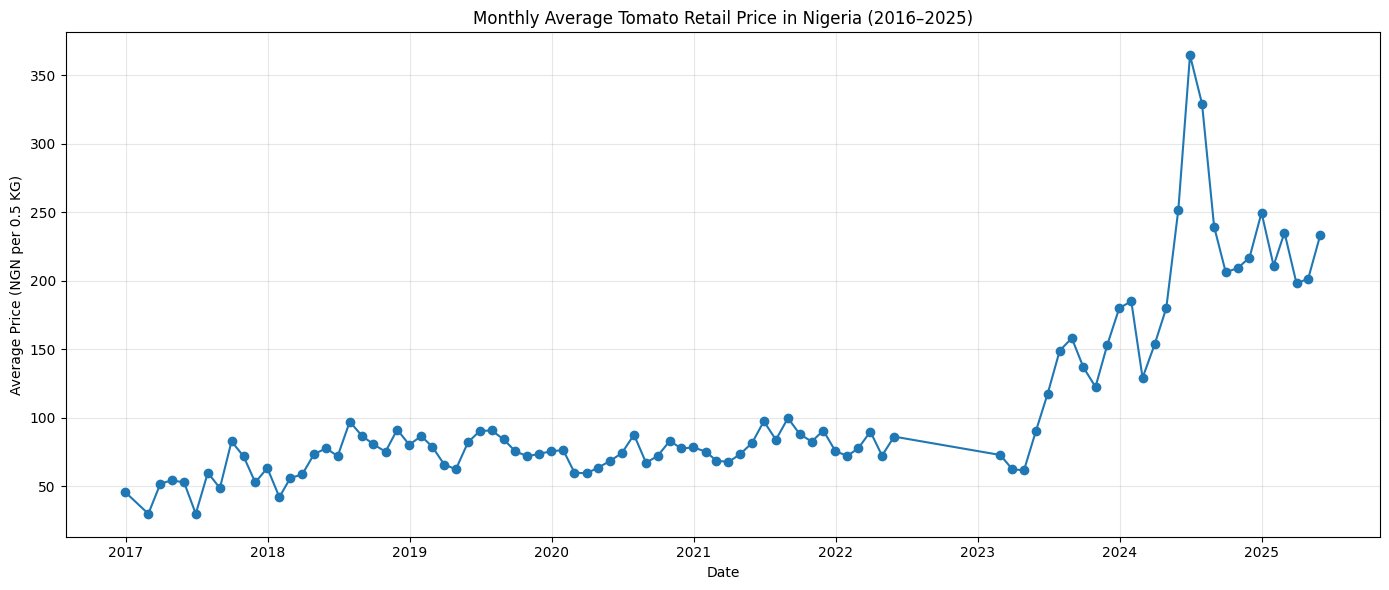

In [15]:
# Visualize monthly tomato prices

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_tomato['date'],
    monthly_tomato['price'],
    marker='o',
    linewidth=1.5
)

plt.title('Monthly Average Tomato Retail Price in Nigeria (2016–2025)')
plt.xlabel('Date')
plt.ylabel('Average Price (NGN per 0.5 KG)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [16]:
# Identify missing calendar months

# Create the complete monthly date range
complete_dates = pd.date_range(
    start=monthly_tomato['date'].min(),
    end=monthly_tomato['date'].max(),
    freq='ME'
)

# Find months that are not present in the dataset
missing_dates = complete_dates[
    ~complete_dates.isin(monthly_tomato['date'])
]

print("Number of missing months:", len(missing_dates))

print("\nMissing months:")
for date in missing_dates:
    print(date.strftime('%B %Y'))

Number of missing months: 9

Missing months:
January 2017
June 2022
July 2022
August 2022
September 2022
October 2022
November 2022
December 2022
January 2023


In [17]:
# Create the forecasting dataframe

forecast_df = monthly_tomato[['date', 'price']].copy()

# Rename price column for clarity
forecast_df = forecast_df.rename(columns={
    'price': 'tomato_price'
})

# Make sure the data is sorted chronologically
forecast_df = forecast_df.sort_values('date').reset_index(drop=True)

print(forecast_df.head())

print("\nShape:", forecast_df.shape)

print("\nLast 5 observations:")
print(forecast_df.tail())


        date  tomato_price
0 2016-12-31     45.714286
1 2017-02-28     30.000000
2 2017-03-31     52.000000
3 2017-04-30     54.444444
4 2017-05-31     52.857143

Shape: (93, 2)

Last 5 observations:
         date  tomato_price
88 2025-01-31    211.023043
89 2025-02-28    235.178125
90 2025-03-31    198.029167
91 2025-04-30    201.557647
92 2025-05-31    233.333333


In [18]:
# Chronological train-test split
test_size = 12

train = forecast_df.iloc[:-test_size].copy()
test = forecast_df.iloc[-test_size:].copy()

print("Training observations:", len(train))
print("Training observations:", len(test))

print("\nTraining period:")
print(train['date'].min(),"to",train['date'].max())

print("\nTesting period:")
print(test['date'].min(), "to", test['date'].max())

Training observations: 81
Training observations: 12

Training period:
2016-12-31 00:00:00 to 2024-05-31 00:00:00

Testing period:
2024-06-30 00:00:00 to 2025-05-31 00:00:00


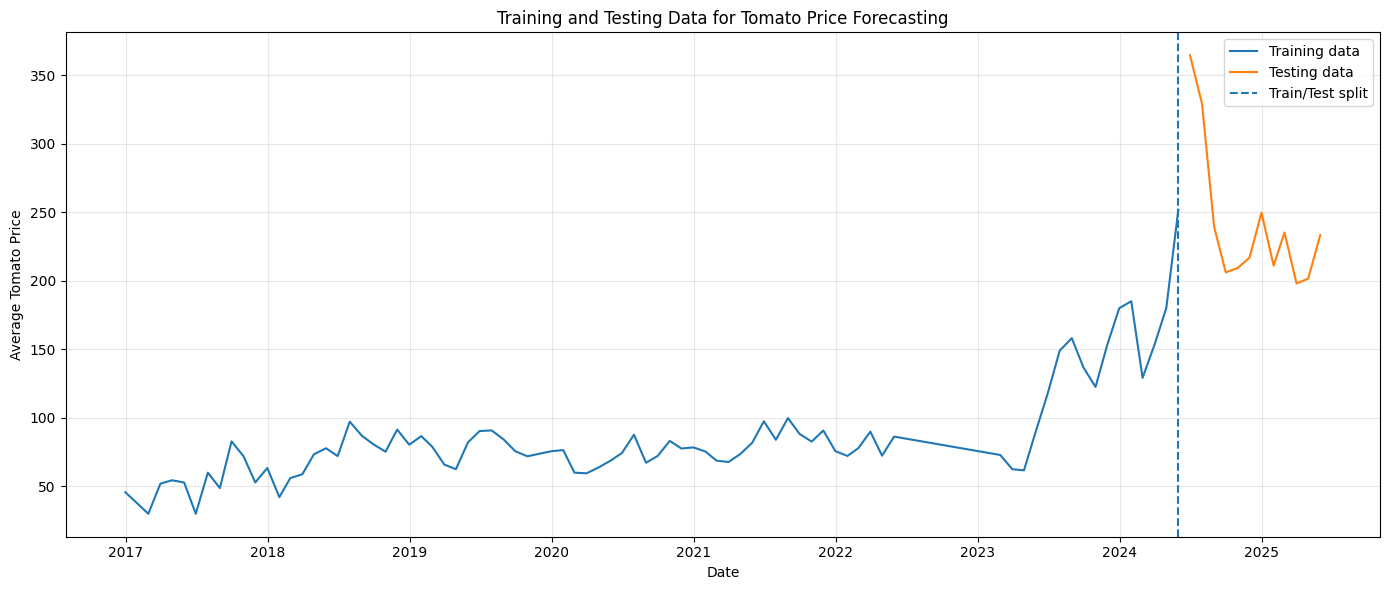

In [19]:
# Visualize training and testing data

plt.figure(figsize=(14, 6))

plt.plot(
    train['date'],
    train['tomato_price'],
    label='Training data',
    linewidth=1.5
)

plt.plot(
    test['date'],
    test['tomato_price'],
    label='Testing data',
    linewidth=1.5
)

plt.axvline(
    train['date'].iloc[-1],
    linestyle='--',
    label='Train/Test split'
)

plt.title('Training and Testing Data for Tomato Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Average Tomato Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Forecasting Methodology

The monthly tomato price series was divided chronologically into training and testing datasets.

The final 12 observations were reserved as a test set, while the earlier observations were used to train the forecasting models.

Three forecasting approaches were evaluated:

1. Naive Forecast
2. Exponential Smoothing
3. ARIMA

The models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [20]:
# Naive forecasting model

naive_prediction = train['tomato_price'].iloc[-1]

test = test.copy()

test['naive_forecast'] = naive_prediction

print(test[['date', 'tomato_price', 'naive_forecast']])


         date  tomato_price  naive_forecast
81 2024-06-30    364.507778      251.907778
82 2024-07-31    329.030000      251.907778
83 2024-08-31    239.473333      251.907778
84 2024-09-30    206.109048      251.907778
85 2024-10-31    209.347500      251.907778
86 2024-11-30    216.865000      251.907778
87 2024-12-31    249.648333      251.907778
88 2025-01-31    211.023043      251.907778
89 2025-02-28    235.178125      251.907778
90 2025-03-31    198.029167      251.907778
91 2025-04-30    201.557647      251.907778
92 2025-05-31    233.333333      251.907778


In [21]:
# Evaluate the naive forecast

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(
    test['tomato_price'],
    test['naive_forecast']
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test['tomato_price'],
        test['naive_forecast']
    )
)

print("Naive Forecast Performance")
print("---------------------------")
print("MAE :", naive_mae)
print("RMSE:", naive_rmse)


Naive Forecast Performance
---------------------------
MAE : 42.352955848100116
RMSE: 51.36284976135865


In [22]:
# Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Use the training prices
train_values = train['tomato_price'].values

# Build the model
ets_model = ExponentialSmoothing(
    train_values,
    trend='add',
    damped_trend=True,
    initialization_method='estimated'
)

# Fit the model
ets_fit = ets_model.fit()

print(ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                   81
Model:             ExponentialSmoothing   SSE                          24504.663
Optimized:                         True   AIC                            472.686
Trend:                         Additive   BIC                            484.658
Seasonal:                          None   AICC                           474.220
Seasonal Periods:                  None   Date:                 Thu, 20 Aug 2026
Box-Cox:                          False   Time:                         06:39:01
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428729                alpha                 True
smoothing_trend             0.0000

In [23]:
# Generate Exponential Smoothing forecasts

ets_forecast = ets_fit.forecast(len(test))

# Add forecasts to the test dataframe
test['ets_forecast'] = ets_forecast

print(test[['date', 'tomato_price', 'ets_forecast']])

         date  tomato_price  ets_forecast
81 2024-06-30    364.507778    249.625741
82 2024-07-31    329.030000    251.418284
83 2024-08-31    239.473333    253.201863
84 2024-09-30    206.109048    254.976525
85 2024-10-31    209.347500    256.742314
86 2024-11-30    216.865000    258.499273
87 2024-12-31    249.648333    260.247448
88 2025-01-31    211.023043    261.986881
89 2025-02-28    235.178125    263.717618
90 2025-03-31    198.029167    265.439701
91 2025-04-30    201.557647    267.153174
92 2025-05-31    233.333333    268.858079


In [24]:
#  Evaluate Exponential Smoothing

ets_mae = mean_absolute_error(
    test['tomato_price'],
    test['ets_forecast']
)

ets_rmse = np.sqrt(
    mean_squared_error(
        test['tomato_price'],
        test['ets_forecast']
    )
)

print("Exponential Smoothing Performance")
print("----------------------------------")
print("MAE :", ets_mae)
print("RMSE:", ets_rmse)


Exponential Smoothing Performance
----------------------------------
MAE : 50.229341546560654
RMSE: 57.30820342427953


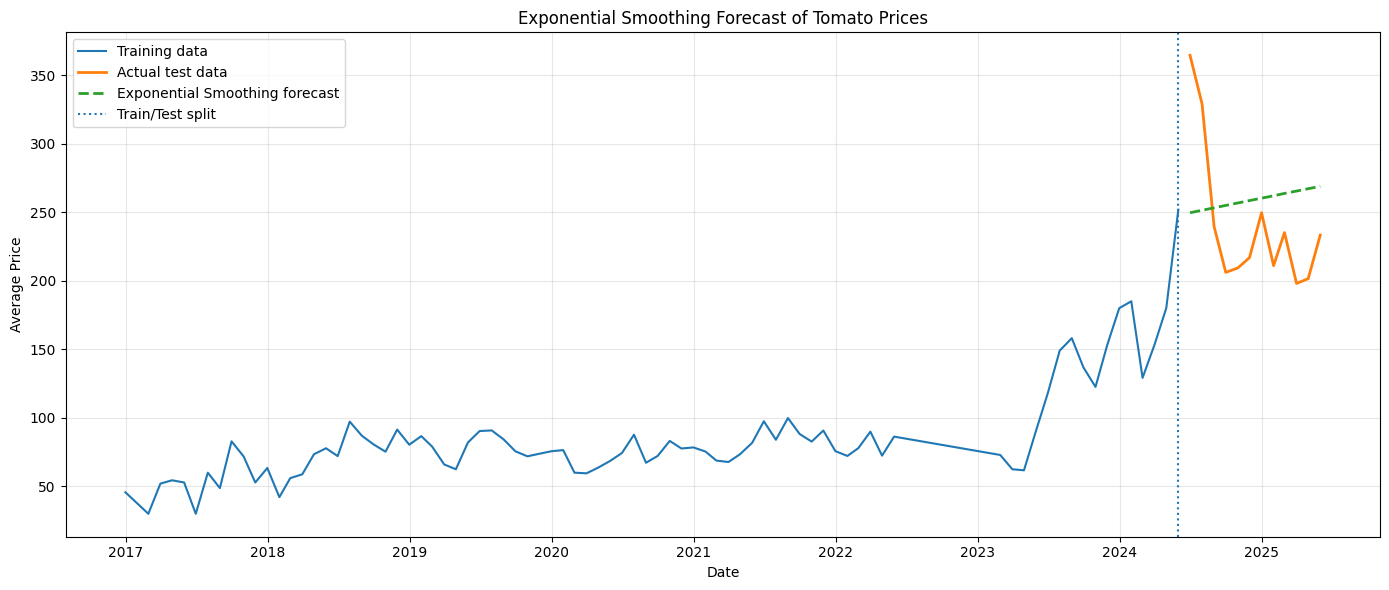

In [25]:
# Plot Exponential Smoothing forecast

plt.figure(figsize=(14, 6))

plt.plot(
    train['date'],
    train['tomato_price'],
    label='Training data'
)

plt.plot(
    test['date'],
    test['tomato_price'],
    label='Actual test data',
    linewidth=2
)

plt.plot(
    test['date'],
    test['ets_forecast'],
    label='Exponential Smoothing forecast',
    linestyle='--',
    linewidth=2
)

plt.axvline(
    train['date'].iloc[-1],
    linestyle=':',
    label='Train/Test split'
)

plt.title('Exponential Smoothing Forecast of Tomato Prices')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
# Prepare data for ARIMA

from statsmodels.tsa.arima.model import ARIMA

# Extract training prices
arima_train = train['tomato_price'].values

print("Number of training observations:", len(arima_train))
print("First 5 training prices:", arima_train[:5])


Number of training observations: 81
First 5 training prices: [45.71428571 30.         52.         54.44444444 52.85714286]


In [27]:
# Test several ARIMA models

arima_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1)
]

arima_results = []

for order in arima_orders:
    try:
        model = ARIMA(arima_train, order=order)
        fitted_model = model.fit()

        forecast = fitted_model.forecast(steps=len(test))

        mae = mean_absolute_error(
            test['tomato_price'],
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test['tomato_price'],
                forecast
            )
        )

        arima_results.append({
            'ARIMA Order': order,
            'MAE': mae,
            'RMSE': rmse
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

arima_results_df = pd.DataFrame(arima_results)

print(arima_results_df.sort_values('RMSE'))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA Order        MAE       RMSE
2   (1, 1, 1)  32.263047  48.376553
4   (0, 1, 2)  33.201404  49.641619
3   (2, 1, 0)  37.857843  49.678627
5   (2, 1, 1)  31.765836  49.874190
1   (0, 1, 1)  40.831792  50.933732
0   (1, 1, 0)  41.119247  51.016278


In [28]:
# Select the best ARIMA model

best_arima_row = arima_results_df.loc[
    arima_results_df['RMSE'].idxmin()
]

best_order = best_arima_row['ARIMA Order']

print("Best ARIMA order:", best_order)
print("Best ARIMA MAE:", best_arima_row['MAE'])
print("Best ARIMA RMSE:", best_arima_row['RMSE'])


Best ARIMA order: (1, 1, 1)
Best ARIMA MAE: 32.263046778454104
Best ARIMA RMSE: 48.37655277032031


In [29]:
# Fit the selected ARIMA model

best_arima_model = ARIMA(
    arima_train,
    order=best_order
)

best_arima_fit = best_arima_model.fit()

# Generate forecasts
arima_forecast = best_arima_fit.forecast(
    steps=len(test)
)

# Add forecasts to test dataframe
test['arima_forecast'] = arima_forecast

print(test[['date', 'tomato_price', 'arima_forecast']])


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


         date  tomato_price  arima_forecast
81 2024-06-30    364.507778      239.564193
82 2024-07-31    329.030000      233.096281
83 2024-08-31    239.473333      229.707163
84 2024-09-30    206.109048      227.931300
85 2024-10-31    209.347500      227.000766
86 2024-11-30    216.865000      226.513175
87 2024-12-31    249.648333      226.257683
88 2025-01-31    211.023043      226.123808
89 2025-02-28    235.178125      226.053659
90 2025-03-31    198.029167      226.016901
91 2025-04-30    201.557647      225.997641
92 2025-05-31    233.333333      225.987548


In [30]:
# Evaluate the best ARIMA model

arima_mae = mean_absolute_error(
    test['tomato_price'],
    test['arima_forecast']
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test['tomato_price'],
        test['arima_forecast']
    )
)

print("Best ARIMA Performance")
print("----------------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)


Best ARIMA Performance
----------------------
MAE : 32.263046778454104
RMSE: 48.37655277032031


In [31]:
print("Selected ARIMA model:", best_order)

Selected ARIMA model: (1, 1, 1)


## 6. Model Evaluation and Selection

The three forecasting models were evaluated using MAE and RMSE. Lower values indicate better forecasting performance.

ARIMA(1,1,1) achieved the lowest MAE and RMSE among the three models. It was therefore selected as the preferred forecasting model for the final forecast.

In [32]:
# Final model comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Naive Forecast',
        'Exponential Smoothing',
        'ARIMA'
    ],
    'MAE': [
        naive_mae,
        ets_mae,
        arima_mae
    ],
    'RMSE': [
        naive_rmse,
        ets_rmse,
        arima_rmse
    ]
})

model_comparison = model_comparison.sort_values(
    'RMSE'
).reset_index(drop=True)

print(model_comparison)


                   Model        MAE       RMSE
0                  ARIMA  32.263047  48.376553
1         Naive Forecast  42.352956  51.362850
2  Exponential Smoothing  50.229342  57.308203


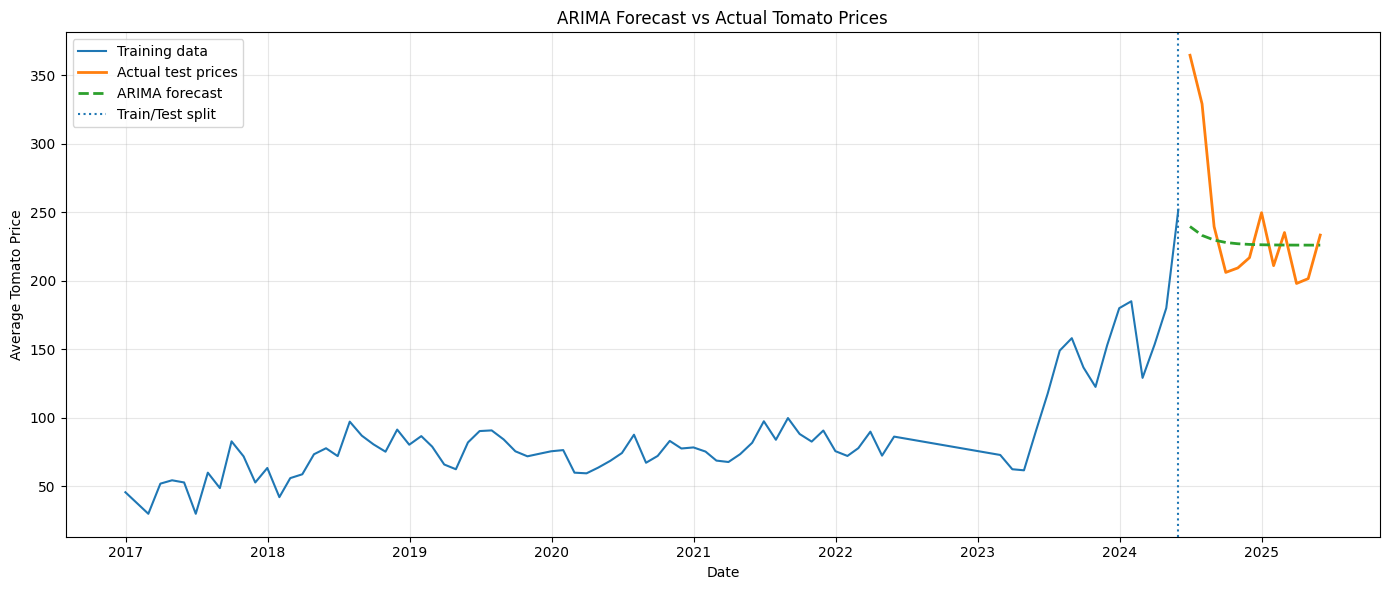

In [33]:
# Plot ARIMA predictions against actual prices

plt.figure(figsize=(14, 6))

plt.plot(
    train['date'],
    train['tomato_price'],
    label='Training data'
)

plt.plot(
    test['date'],
    test['tomato_price'],
    label='Actual test prices',
    linewidth=2
)

plt.plot(
    test['date'],
    test['arima_forecast'],
    label='ARIMA forecast',
    linestyle='--',
    linewidth=2
)

plt.axvline(
    train['date'].iloc[-1],
    linestyle=':',
    label='Train/Test split'
)

plt.title('ARIMA Forecast vs Actual Tomato Prices')
plt.xlabel('Date')
plt.ylabel('Average Tomato Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
# Fit final ARIMA(1,1,1) model using all available data

# Get all available tomato prices
full_series = forecast_df['tomato_price'].values

# Fit ARIMA(1,1,1)
final_arima_model = ARIMA(
    full_series,
    order=(1, 1, 1)
)

final_arima_fit = final_arima_model.fit()

print(final_arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   93
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -422.094
Date:                Thu, 20 Aug 2026   AIC                            850.188
Time:                        07:24:08   BIC                            857.753
Sample:                             0   HQIC                           853.241
                                 - 93                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7089      0.272      2.608      0.009       0.176       1.242
ma.L1         -0.8327      0.203     -4.096      0.000      -1.231      -0.434
sigma2       565.1188     48.480     11.657      0.0

In [35]:
# Forecast the next 12 months

forecast_steps = 12

future_forecast = final_arima_fit.forecast(
    steps=forecast_steps
)

# Create future dates
future_dates = pd.date_range(
    start=forecast_df['date'].max() + pd.offsets.MonthEnd(1),
    periods=forecast_steps,
    freq='ME'
)

# Create forecast dataframe
future_forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_price': future_forecast
})

print(future_forecast_df)

         date  forecast_price
0  2025-06-30      231.236353
1  2025-07-31      229.749792
2  2025-08-31      228.695961
3  2025-09-30      227.948895
4  2025-10-31      227.419296
5  2025-11-30      227.043860
6  2025-12-31      226.777712
7  2026-01-31      226.589038
8  2026-02-28      226.455286
9  2026-03-31      226.360468
10 2026-04-30      226.293252
11 2026-05-31      226.245601


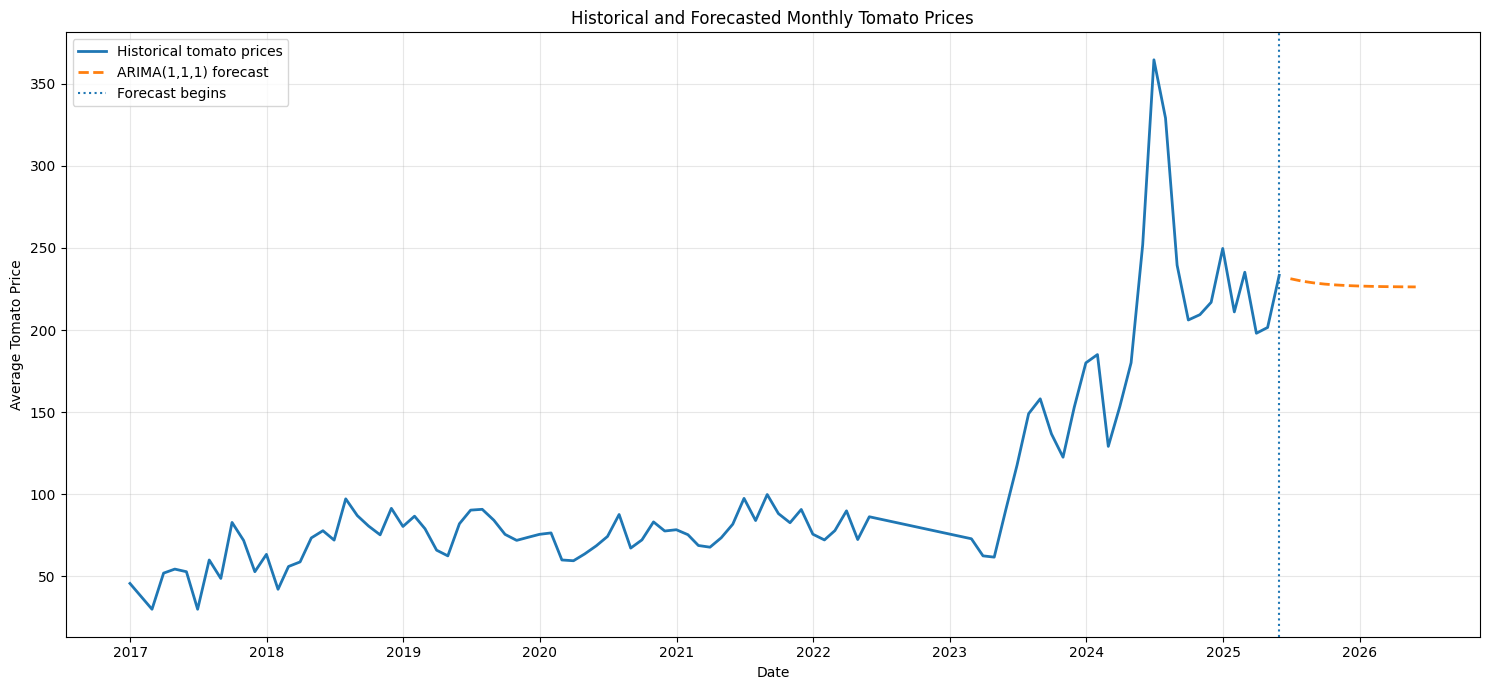

In [36]:
# Plot historical prices and future ARIMA forecast

plt.figure(figsize=(15, 7))

# Historical data
plt.plot(
    forecast_df['date'],
    forecast_df['tomato_price'],
    label='Historical tomato prices',
    linewidth=2
)

# Future forecast
plt.plot(
    future_forecast_df['date'],
    future_forecast_df['forecast_price'],
    label='ARIMA(1,1,1) forecast',
    linestyle='--',
    linewidth=2
)

# Mark where forecasting begins
plt.axvline(
    forecast_df['date'].max(),
    linestyle=':',
    label='Forecast begins'
)

plt.title(
    'Historical and Forecasted Monthly Tomato Prices'
)
plt.xlabel('Date')
plt.ylabel('Average Tomato Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Final Tomato Price Forecast

The selected ARIMA(1,1,1) model was refitted using all 93 available monthly observations and used to generate a 12-month forecast.

The forecast covers June 2025 to May 2026.

The model predicts a gradual decline in the central forecast from 231.24 in June 2025 to 226.25 in May 2026.

The average forecast price over the 12-month period is 227.57.

In [37]:
# Summarize the future forecast

print("ARIMA(1,1,1) 12-Month Forecast")
print("--------------------------------")

print(
    "Forecast period:",
    future_forecast_df['date'].min().strftime('%B %Y'),
    "to",
    future_forecast_df['date'].max().strftime('%B %Y')
)

print(
    "\nMinimum forecast price:",
    round(future_forecast_df['forecast_price'].min(), 2)
)

print(
    "Maximum forecast price:",
    round(future_forecast_df['forecast_price'].max(), 2)
)

print(
    "Average forecast price:",
    round(future_forecast_df['forecast_price'].mean(), 2)
)

print("\nForecast table:")
print(future_forecast_df.round(2))


ARIMA(1,1,1) 12-Month Forecast
--------------------------------
Forecast period: June 2025 to May 2026

Minimum forecast price: 226.25
Maximum forecast price: 231.24
Average forecast price: 227.57

Forecast table:
         date  forecast_price
0  2025-06-30          231.24
1  2025-07-31          229.75
2  2025-08-31          228.70
3  2025-09-30          227.95
4  2025-10-31          227.42
5  2025-11-30          227.04
6  2025-12-31          226.78
7  2026-01-31          226.59
8  2026-02-28          226.46
9  2026-03-31          226.36
10 2026-04-30          226.29
11 2026-05-31          226.25


In [38]:
# Save the forecast results

future_forecast_df.to_csv(
    'tomato_price_forecast_2025_2026.csv',
    index=False
)

print("Forecast saved successfully.")


Forecast saved successfully.


In [39]:
# Final model comparison table

final_comparison = pd.DataFrame({
    'Model': [
        'Naive Forecast',
        'Exponential Smoothing',
        'ARIMA(1,1,1)'
    ],
    'MAE': [
        naive_mae,
        ets_mae,
        arima_mae
    ],
    'RMSE': [
        naive_rmse,
        ets_rmse,
        arima_rmse
    ]
})

final_comparison = final_comparison.round(2)

print(final_comparison)


                   Model    MAE   RMSE
0         Naive Forecast  42.35  51.36
1  Exponential Smoothing  50.23  57.31
2           ARIMA(1,1,1)  32.26  48.38


In [40]:
# Generate ARIMA forecasts with 95% prediction intervals

forecast_result = final_arima_fit.get_forecast(steps=12)

forecast_mean = forecast_result.predicted_mean

forecast_interval = forecast_result.conf_int(alpha=0.05)

final_forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_price': forecast_mean.values,
    'lower_95': forecast_interval.iloc[:, 0].values,
    'upper_95': forecast_interval.iloc[:, 1].values
})

print(final_forecast_df.round(2))


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [41]:
# Generate ARIMA forecasts with 95% prediction intervals

forecast_result = final_arima_fit.get_forecast(steps=12)

# Get forecast values
forecast_mean = forecast_result.predicted_mean

# Get 95% prediction intervals
forecast_interval = forecast_result.conf_int(alpha=0.05)

# Convert everything safely to NumPy arrays
forecast_mean = np.asarray(forecast_mean)
forecast_interval = np.asarray(forecast_interval)

# Create final forecast dataframe
final_forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_price': forecast_mean,
    'lower_95': forecast_interval[:, 0],
    'upper_95': forecast_interval[:, 1]
})

print(final_forecast_df.round(2))


         date  forecast_price  lower_95  upper_95
0  2025-06-30          231.24    184.64    277.83
1  2025-07-31          229.75    167.80    291.70
2  2025-08-31          228.70    156.67    300.72
3  2025-09-30          227.95    148.37    307.53
4  2025-10-31          227.42    141.73    313.11
5  2025-11-30          227.04    136.14    317.95
6  2025-12-31          226.78    131.27    322.28
7  2026-01-31          226.59    126.90    326.28
8  2026-02-28          226.46    122.90    330.01
9  2026-03-31          226.36    119.17    333.55
10 2026-04-30          226.29    115.65    336.94
11 2026-05-31          226.25    112.30    340.19


In [42]:
print("\nForecast summary:")
print("Minimum forecast:", round(final_forecast_df['forecast_price'].min(), 2))
print("Maximum forecast:", round(final_forecast_df['forecast_price'].max(), 2))
print("Average forecast:", round(final_forecast_df['forecast_price'].mean(), 2))


Forecast summary:
Minimum forecast: 226.25
Maximum forecast: 231.24
Average forecast: 227.57


 7. Results and Discussion

## 7.1 Model Performance

Three forecasting models were evaluated using a 12-month holdout test set: Naive Forecast, Exponential Smoothing, and ARIMA(1,1,1).

The models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better forecasting performance.

| Model | MAE | RMSE |
|---|---:|---:|
| Naive Forecast | 42.35 | 51.36 |
| Exponential Smoothing | 50.23 | 57.31 |
| ARIMA(1,1,1) | 32.26 | 48.38 |

ARIMA(1,1,1) produced the best overall performance, with the lowest MAE of 32.26 and the lowest RMSE of 48.38. Therefore, ARIMA(1,1,1) was selected as the preferred forecasting model.

The Naive Forecast produced an MAE of 42.35 and an RMSE of 51.36. Although this model is simple, it provided a useful baseline for evaluating whether more advanced forecasting methods could improve predictive performance.

Exponential Smoothing performed less well than both the Naive Forecast and ARIMA(1,1,1), with an MAE of 50.23 and an RMSE of 57.31.

Compared with the Naive Forecast, ARIMA(1,1,1) reduced the MAE by approximately 23.8%. Its RMSE was also lower, decreasing from 51.36 to 48.38. These results indicate that ARIMA was better able to capture the underlying temporal behaviour of the tomato price series during the test period.


## 7.2 Twelve-Month Forecast

After model evaluation, ARIMA(1,1,1) was selected as the best-performing model. The model was then refitted using all 93 available monthly tomato price observations and used to generate a 12-month forecast.

The forecast period covers June 2025 to May 2026.

| Month | Forecast Price |
|---|---:|
| June 2025 | 231.24 |
| July 2025 | 229.75 |
| August 2025 | 228.70 |
| September 2025 | 227.95 |
| October 2025 | 227.42 |
| November 2025 | 227.04 |
| December 2025 | 226.78 |
| January 2026 | 226.59 |
| February 2026 | 226.46 |
| March 2026 | 226.36 |
| April 2026 | 226.29 |
| May 2026 | 226.25 |

The forecast has a maximum predicted price of 231.24 and a minimum predicted price of 226.25. The average forecast price across the 12-month period is 227.57.

The central forecast shows a gradual decline in tomato prices over the forecast period. The predicted price decreases by approximately 4.99 price units between June 2025 and May 2026, representing a decline of approximately 2.16%.

The relatively small change in the central forecast suggests that the ARIMA model expects tomato prices to remain broadly stable over the forecast horizon, with a modest downward movement rather than a sharp increase or decrease.



## 7.3 Forecast Uncertainty

In addition to the central forecast, the ARIMA(1,1,1) model produced 95% prediction intervals.

For June 2025, the central forecast is 231.24, with a 95% prediction interval of approximately 184.64 to 277.83. By May 2026, the central forecast is 226.25, while the prediction interval has widened to approximately 112.30 to 340.19.

The widening prediction intervals indicate that uncertainty increases as the forecasting horizon becomes longer. Therefore, although the central forecasts suggest relatively stable prices, there is considerable uncertainty surrounding the exact future price values, particularly for the later forecast months.

The prediction intervals therefore provide important context for interpreting the forecasts. The forecast values should be treated as estimated central values rather than guaranteed future prices.


## 7.4 Overall Interpretation

The results show that ARIMA(1,1,1) provided the best predictive performance among the three models evaluated. Its MAE of 32.26 was lower than the Naive Forecast MAE of 42.35 and the Exponential Smoothing MAE of 50.23. Similarly, its RMSE of 48.38 was lower than the Naive Forecast RMSE of 51.36 and the Exponential Smoothing RMSE of 57.31.

The superior performance of ARIMA suggests that incorporating the temporal structure of the tomato price series improved forecasting accuracy compared with the simpler approaches evaluated.

The final ARIMA forecast indicates relatively stable tomato prices during the 12-month forecast period, with a gradual decline from 231.24 in June 2025 to 226.25 in May 2026. However, the widening prediction intervals demonstrate that longer-term forecasts contain greater uncertainty.

Overall, the findings demonstrate that time-series modelling can provide useful quantitative estimates of future tomato prices, while also highlighting the importance of accounting for uncertainty when interpreting forecasts.




## 8. Forecast Uncertainty

The ARIMA model also produced 95% prediction intervals around the point forecasts.

The prediction intervals become wider as the forecast horizon increases. This indicates increasing uncertainty about the precise future price as the forecasting period extends further from the historical data.

Therefore, the point forecasts should be interpreted as estimated central values rather than guaranteed future prices.

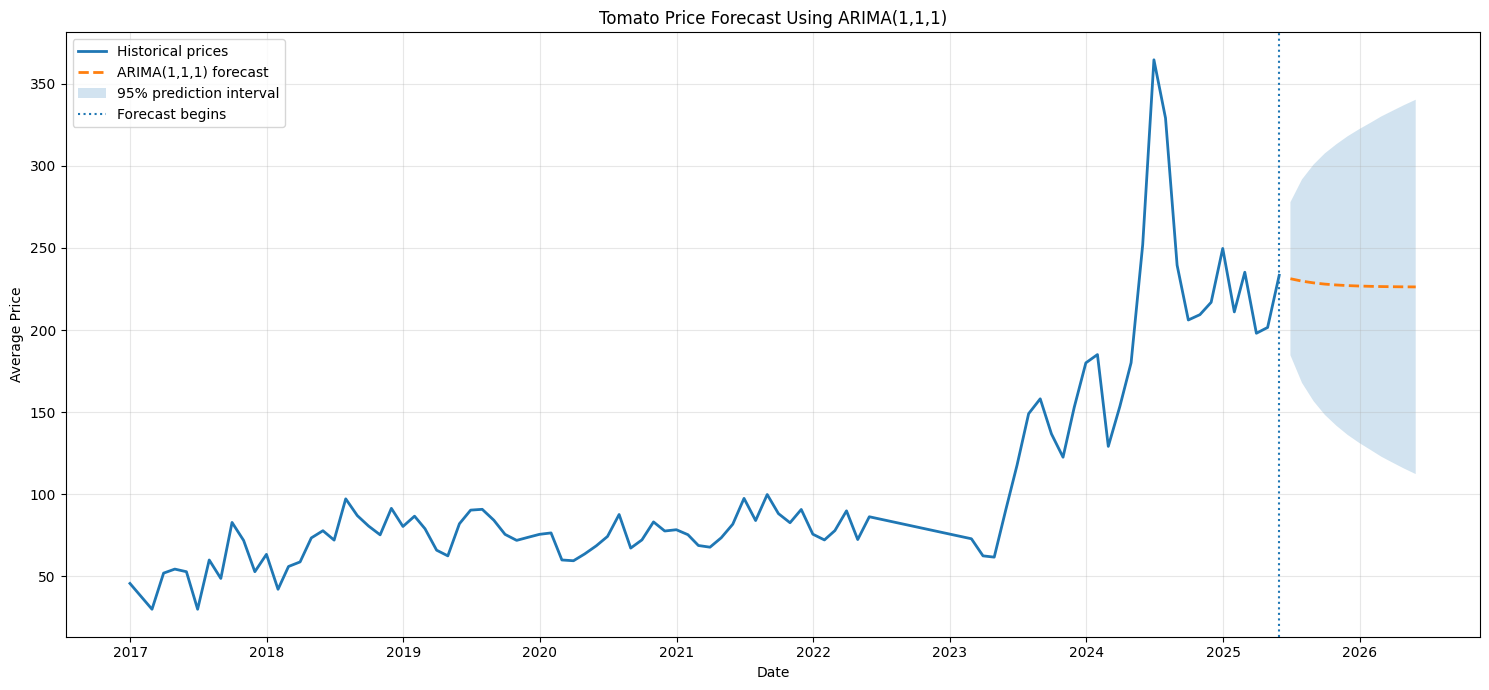

In [43]:
# Final ARIMA forecast with 95% prediction interval

plt.figure(figsize=(15, 7))

# Historical prices
plt.plot(
    forecast_df['date'],
    forecast_df['tomato_price'],
    label='Historical prices',
    linewidth=2
)

# Forecast
plt.plot(
    final_forecast_df['date'],
    final_forecast_df['forecast_price'],
    label='ARIMA(1,1,1) forecast',
    linestyle='--',
    linewidth=2
)

# 95% prediction interval
plt.fill_between(
    final_forecast_df['date'],
    final_forecast_df['lower_95'],
    final_forecast_df['upper_95'],
    alpha=0.2,
    label='95% prediction interval'
)

# Forecast starting point
plt.axvline(
    forecast_df['date'].max(),
    linestyle=':',
    label='Forecast begins'
)

plt.title('Tomato Price Forecast Using ARIMA(1,1,1)')
plt.xlabel('Date')
plt.ylabel('Average Price')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Save final forecast results

final_forecast_df.round(2).to_csv(
    'final_tomato_arima_forecast.csv',
    index=False
)

print("Final forecast saved successfully.")

Final forecast saved successfully.


In [45]:
# Final project results summary

print("=" * 60)
print("TOMATO PRICE FORECASTING — FINAL RESULTS")
print("=" * 60)

print("\nDATA")
print("Monthly observations:", len(forecast_df))
print(
    "Historical period:",
    forecast_df['date'].min().strftime('%B %Y'),
    "to",
    forecast_df['date'].max().strftime('%B %Y')
)

print("\nMODEL PERFORMANCE")
print(final_comparison)

print("\nSELECTED MODEL")
print("ARIMA(1,1,1)")

print("\n12-MONTH FORECAST")
print(
    "Forecast period:",
    final_forecast_df['date'].min().strftime('%B %Y'),
    "to",
    final_forecast_df['date'].max().strftime('%B %Y')
)

print(
    "Average forecast:",
    round(final_forecast_df['forecast_price'].mean(), 2)
)

print(
    "Minimum forecast:",
    round(final_forecast_df['forecast_price'].min(), 2)
)

print(
    "Maximum forecast:",
    round(final_forecast_df['forecast_price'].max(), 2)
)

print("\nFINAL FORECAST")
print(final_forecast_df.round(2))


TOMATO PRICE FORECASTING — FINAL RESULTS

DATA
Monthly observations: 93
Historical period: December 2016 to May 2025

MODEL PERFORMANCE
                   Model    MAE   RMSE
0         Naive Forecast  42.35  51.36
1  Exponential Smoothing  50.23  57.31
2           ARIMA(1,1,1)  32.26  48.38

SELECTED MODEL
ARIMA(1,1,1)

12-MONTH FORECAST
Forecast period: June 2025 to May 2026
Average forecast: 227.57
Minimum forecast: 226.25
Maximum forecast: 231.24

FINAL FORECAST
         date  forecast_price  lower_95  upper_95
0  2025-06-30          231.24    184.64    277.83
1  2025-07-31          229.75    167.80    291.70
2  2025-08-31          228.70    156.67    300.72
3  2025-09-30          227.95    148.37    307.53
4  2025-10-31          227.42    141.73    313.11
5  2025-11-30          227.04    136.14    317.95
6  2025-12-31          226.78    131.27    322.28
7  2026-01-31          226.59    126.90    326.28
8  2026-02-28          226.46    122.90    330.01
9  2026-03-31          226.36 

## 9. Limitations

This study has several limitations.

First, although the period from December 2016 to May 2025 contains 102 calendar months, the dataset provided 93 observed monthly averages. Therefore, some calendar months did not have observations.

Second, the analysis focuses on historical price patterns and does not explicitly incorporate external factors such as weather conditions, seasonal production, transportation costs, inflation, exchange rates, or changes in supply and demand.

Third, the prediction intervals become increasingly wide over the 12-month forecast horizon, indicating substantial uncertainty in longer-term forecasts.

Finally, the study compares only three forecasting approaches. Other methods could potentially produce different results.


## 10. Conclusion

This project developed a time-series forecasting model for monthly tomato retail prices using historical data from December 2016 to May 2025.

Three forecasting methods were evaluated: Naive Forecast, Exponential Smoothing, and ARIMA. Based on the MAE and RMSE results, ARIMA(1,1,1) was the best-performing model, achieving an MAE of 32.26 and an RMSE of 48.38.

The selected model was subsequently fitted using all 93 available monthly observations and used to forecast tomato prices from June 2025 to May 2026.

The central forecasts indicate relatively stable tomato prices with a gradual downward movement during the forecast period. However, the widening prediction intervals demonstrate that uncertainty increases as the forecast horizon becomes longer.

Overall, the project demonstrates how time-series forecasting can be used to analyse historical tomato prices and provide quantitative estimates of future price behaviour.


## 11. Recommendations

Based on the findings of this study:

1. Tomato producers and traders can use time-series forecasts as one source of information when planning production, purchasing, and inventory decisions.

2. Forecasts should be updated regularly as new monthly price observations become available.

3. Future studies should consider incorporating external variables such as rainfall, temperature, inflation, transportation costs, and supply and demand indicators.

4. Future research could compare ARIMA with additional forecasting approaches, including SARIMA and machine-learning models.

5. Forecasts should be interpreted together with their prediction intervals because future prices remain uncertain.
